# Fig. 5: Effects of mismatching PM/PFA between agent model and search space truth

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from infotaxis import one_target

from scipy import stats

import seaborn as sns

In [2]:
path_fig = Path("../figs")

In [3]:
def load_summary(
    path_csv, search_type, cr, br, pm_agent, pm_truth=None,
    p_max_th=0.95, pmax_diff_threshold=1e-5,
):
    if pm_truth is None:
        return pd.read_csv(
            path_csv / f"{search_type}_cr{cr}_br{br}_pm{pm_agent:.0e}_pfa{pm_agent:.0e}_summary.csv",
            index_col=0
        )
    else:
        return pd.read_csv(
            path_csv / (
                f"{search_type}_cr{cr}_br{br}_pmAgent{pm_agent:.0e}_pfaAgent{pm_agent:.0e}_pmTruth{pm_truth:.0e}_pfaTruth{pm_truth:.0e}"
                f"_summary_pMaxTh{p_max_th:.1e}_pMaxDiffTh{pmax_diff_threshold:.0e}.csv"
            ),
            index_col=0
        )

In [4]:
def get_stats(x, y, print_stats=True):
    stats_dict = dict()
    stats_dict["two-sided"] = stats.mannwhitneyu(x, y, alternative="two-sided")
    stats_dict["less"] = stats.mannwhitneyu(x, y, alternative="less")
    stats_dict["greater"] = stats.mannwhitneyu(x, y, alternative="greater")

    if print_stats:
        print("---------------------------------------------")
        print(f"Samples: default: {len(x):4d}    restrict beam movement: {len(y):4d}")
        print(f"Mean:    default: {np.mean(x):.3f}  restrict beam movement: {np.mean(y):.3f}")
        print(f"Median:  default: {np.median(x):.3f}  restrict beam movement: {np.median(y):.3f}")
        print("")
        print("MWU test")
        print(f" - different: {stats_dict["two-sided"].pvalue:.5f}")
        print(f" - less:      {stats_dict["less"].pvalue:.5f}")
        print(f" - greater:   {stats_dict["greater"].pvalue:.5f}")

    return stats_dict

In [5]:
def bar_violinplot_success(
    cr, br, pm_agent_all, pm_truth_all,
    success_type="success_pmax_th",
    p_max_th=0.95, pmax_diff_threshold=1e-5,
    alpha=0.65, ping_bins=np.arange(0, 155, 5), print_stats=True
):

    # Get search space grid info
    search_dict = None
    param_echo = {
        str(br): {
            "pm_const": 0.001,
            "pfa_const": 0.001,
        },
    }
    oth = one_target.OneTargetHex(
        search_rule="infotaxis",
        canvas_radius=cr,
        beam_radius=[br],
        target_cube=(0, 0, 0),
        aim_start_cube=(-2, 3, -1),
        param_animal= param_echo,
        param_echo= param_echo,
        search_dict=search_dict
    )

    grid_in_beam = oth.beam_cover_last_cube.shape[0]
    grid_in_space = oth.canvas_cube.shape[0]
    alpha_grid = grid_in_beam / grid_in_space

    # Get colors for plotting
    colors = sns.color_palette("Set2")
    colors_dark = sns.color_palette("Dark2")

    # Plot
    colors = sns.color_palette("Set2")
    colors_dark = sns.color_palette("Dark2")

    fig, axes = plt.subplots(
        # 2, len(pm_agent_all), figsize=(8, 4.5), sharey="row",  # for 6 panels
        2, len(pm_agent_all), figsize=(6, 4.5), sharey="row",  # for 4 panels
        gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05, "wspace": 0}  # Top row is 1/3 height of bottom
    )


    ping_bins_max = None
    for idx, (pm_agent, pm_truth) in enumerate(zip(pm_agent_all, pm_truth_all)):

        # Load summary and ph details
        df_x = load_summary(
            path_csv=Path("../simulations/20251027_summary_refined"),
            search_type="infotaxis", cr=cr, br=br, pm_agent=pm_agent  # pm_truth=pm_agent here
        )
        df_y = load_summary(
            path_csv=Path("../simulations/20251119_summary_refined"),
            search_type="infotaxis", cr=cr, br=br, pm_agent=pm_agent, pm_truth=pm_truth,
            p_max_th=p_max_th, pmax_diff_threshold=pmax_diff_threshold,
        )
        
        # Plot only successful runs
        x = df_x[df_x["num_grid_left"]==1]["num_pings_2conditions"].values
        y = df_y[df_y[success_type]]["num_pings_2conditions"].values

        # Print statistics
        stats_dict = get_stats(x, y, print_stats)


        # Plotting success rate
        ax_s = axes[0, idx]
        bar_x = ax_s.bar(-0.5, len(x)/1000*100, width=0.4, color=colors[0], alpha=alpha)
        bar_y = ax_s.bar(0.5, len(y)/1000*100, width=0.4, color=colors[2], alpha=alpha)
        ax_s.text(-0.5, len(x)/1000*100+5, (f"({len(x)})"), ha="center", va="bottom", fontsize=9)
        ax_s.text(0.5, len(y)/1000*100+5, (f"({len(y)})"), ha="center", va="bottom", fontsize=9)
        ax_s.set_xlim(-1, 1)
        ax_s.set_ylim(0, 140)
        ax_s.set_title(f"{pm_truth}")



        # Plotting number of pings to success
        ping_bins = np.arange(0, np.ceil(np.hstack((x, y)).max())+10, 5)
        if ping_bins_max is None:
            ping_bins_max = ping_bins
        else:
            ping_bins_max = ping_bins if ping_bins_max[-1] < ping_bins[-1] else ping_bins_max

        ax_n = axes[1, idx]

        x_hist, x_bins = np.histogram(x, bins=ping_bins, density=True)
        y_hist, y_bins = np.histogram(y, bins=ping_bins, density=True)
        x_median = np.median(x)
        y_median = np.median(y)

        ax_n.barh(x_bins[:-1], -x_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[0], alpha=alpha)
        ax_n.barh(y_bins[:-1], y_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[2], alpha=alpha)        
        ax_s.set_xticks([])
        ax_s.set_xticklabels("")

        # Get x-axis limits
        xlim = ax_n.get_xlim()
        xlim = np.max([max(xlim), -min(xlim)])
        xlim = xlim + 0.1*np.max(xlim)
        ax_n.set_xlim(-xlim, xlim)
        ax_n.axhline(x_median, xmin=0.0, xmax=0.5, color=colors_dark[0], solid_capstyle="butt", lw=2.5)
        ax_n.axhline(y_median, xmin=0.51, xmax=1, color=colors_dark[2], solid_capstyle="butt", lw=2.5)

        # label sample number
        ax_n.set_xticks([])
        ax_n.set_xticklabels("")
        
        # label p-value for alternative="less"
        ax_n.text(
            0.975, 0.93, f"p={stats_dict["two-sided"].pvalue:.0e}",
            ha="right", va="center",
            transform=ax_n.transAxes,
            fontsize=11, 
        )

        ax_n.tick_params(direction='in', which='both')
        # if idx != 0:
        if ping_bins[-1] > 200:
            ax_n.set_yticks(ping_bins_max[::8])
        else:
            ax_n.set_yticks(ping_bins_max[::4])

    # make title line
    axes[0, 0].text(
        # -4.75, 1.02, r"$P_M^T=P_{FA}^T$=",  # for 6 panels
        -2.75, 1.02, r"$P_M^T=P_{FA}^T$=",  # for 4 panels
        ha="right", va="bottom",
        transform=ax_s.transAxes,
        fontsize=12,
    )

    axes[0, 0].set_ylabel("Success\nrate (%)", fontsize=12)    
    axes[1, 0].set_ylabel("Number of pings\nto success", fontsize=12)
    fig.text(0.5, 0.97, fr"$\mathbfit{{\alpha}}$={alpha_grid:.3f}  ($\mathbfit{{r_A}}$={cr}, $\mathbfit{{r_B}}$={br})",
        ha="center", va="center", fontsize=12, fontweight="bold")
    # fig.text(0.5, 0.97, fr"Space radius={cr}, footprint radius={br} ($\alpha$={alpha_grid:.3f})",
    #     ha="center", va="center", fontsize=12)

   # Add single horizontal legend below all panels
    fig.legend(
        handles=[bar_x, bar_y],
        labels=['Matched', 'Mismatched'],
        loc='lower center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.005),
        # frameon=False,
        fontsize=11
    )    

    # plt.tight_layout(pad=0)
    plt.show()

    return fig

## Number of pings until finding 1 grid

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1
---------------------------------------------
Samples: default: 1000    restrict beam movement:  926
Mean:    default: 10.487  restrict beam movement: 10.686
Median:  default: 10.000  restrict beam movement: 10.000

MWU test
 - different: 0.54543
 - less:      0.27271
 - greater:   0.72731
---------------------------------------------
Samples: default: 1000    restrict beam movement:  832
Mean:    default: 10.487  restrict beam movement: 11.019
Median:  default: 10.000  restrict beam movement: 10.000

MWU test
 - different: 0.07533
 - less:      0.03767
 - greater:   0.96234
---------------------------------------------
Samples: default: 1000    restrict beam movement:  618
Mean:    default: 10.487  restrict beam movement: 10.909
Median:  default: 10.000  restrict beam movement: 10.000

MWU test
 - different: 0.79184
 - less:      0.39592
 - greater:   0.60412
------

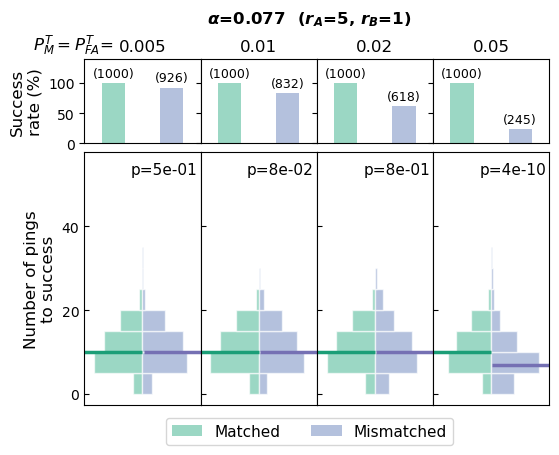

In [6]:
cr = 5
br = 1
# pm_truth_all = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]  # before 20251230
pm_truth_all = [0.005, 0.01, 0.02, 0.05]  # starting 20251230 
pm_agent_all = [0.001] * len(pm_truth_all)

fig = bar_violinplot_success(
    cr, br, pm_agent_all, pm_truth_all,
    success_type="success_2conditions",
    p_max_th=0.95, pmax_diff_threshold=1e-5,
    alpha=0.65, ping_bins=np.arange(0, 155, 5), print_stats=True
)

fig.savefig(path_fig / f"fig_5A_infotaxis_mismatch_agent_truth_cmp_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 2
---------------------------------------------
Samples: default: 1000    restrict beam movement:  890
Mean:    default: 7.537  restrict beam movement: 7.976
Median:  default: 7.000  restrict beam movement: 8.000

MWU test
 - different: 0.00028
 - less:      0.00014
 - greater:   0.99986
---------------------------------------------
Samples: default: 1000    restrict beam movement:  738
Mean:    default: 7.537  restrict beam movement: 8.289
Median:  default: 7.000  restrict beam movement: 8.000

MWU test
 - different: 0.00002
 - less:      0.00001
 - greater:   0.99999
---------------------------------------------
Samples: default: 1000    restrict beam movement:  460
Mean:    default: 7.537  restrict beam movement: 8.248
Median:  default: 7.000  restrict beam movement: 8.000

MWU test
 - different: 0.00441
 - less:      0.00221
 - greater:   0.99779
------------------

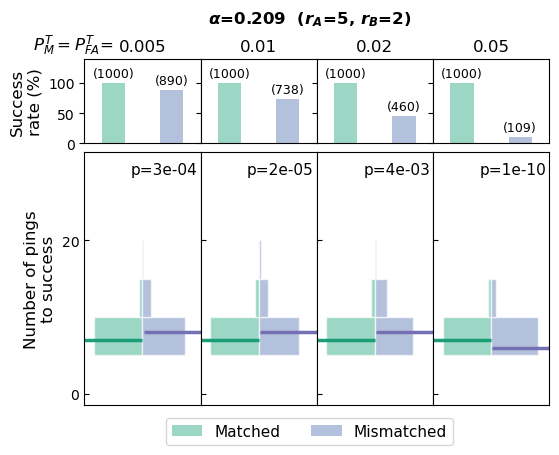

In [7]:
cr = 5
br = 2
# pm_truth_all = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]  # before 20251230
pm_truth_all = [0.005, 0.01, 0.02, 0.05]  # starting 20251230 
pm_agent_all = [0.001] * len(pm_truth_all)

fig = bar_violinplot_success(
    cr, br, pm_agent_all, pm_truth_all,
    success_type="success_2conditions",
    p_max_th=0.95, pmax_diff_threshold=1e-5,
    alpha=0.65, ping_bins=np.arange(0, 155, 5), print_stats=True
)

fig.savefig(path_fig / f"fig_5B_infotaxis_mismatch_agent_truth_cmp_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1
---------------------------------------------
Samples: default: 1000    restrict beam movement:  886
Mean:    default: 29.434  restrict beam movement: 28.893
Median:  default: 28.000  restrict beam movement: 26.500

MWU test
 - different: 0.36655
 - less:      0.81675
 - greater:   0.18328
---------------------------------------------
Samples: default: 1000    restrict beam movement:  707
Mean:    default: 29.434  restrict beam movement: 29.253
Median:  default: 28.000  restrict beam movement: 27.000

MWU test
 - different: 0.43863
 - less:      0.78072
 - greater:   0.21931
---------------------------------------------
Samples: default: 1000    restrict beam movement:  344
Mean:    default: 29.434  restrict beam movement: 24.535
Median:  default: 28.000  restrict beam movement: 21.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
------

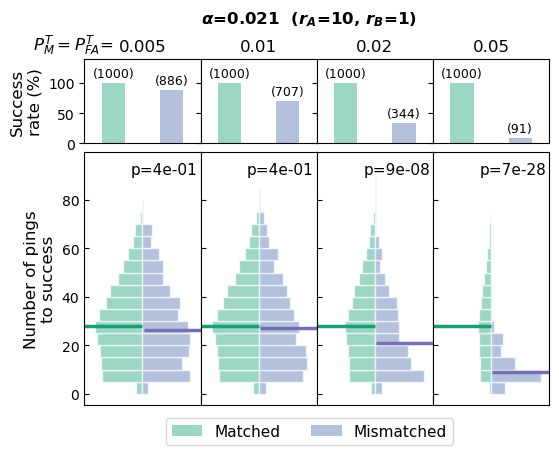

In [8]:
cr = 10
br = 1
# pm_truth_all = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]  # before 20251230
pm_truth_all = [0.005, 0.01, 0.02, 0.05]  # starting 20251230 
pm_agent_all = [0.001] * len(pm_truth_all)

fig = bar_violinplot_success(
    cr, br, pm_agent_all, pm_truth_all,
    success_type="success_2conditions",
    p_max_th=0.95, pmax_diff_threshold=1e-5,
    alpha=0.65, ping_bins=np.arange(0, 155, 5), print_stats=True
)

fig.savefig(path_fig / f"fig_5C_infotaxis_mismatch_agent_truth_cmp_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 2
---------------------------------------------
Samples: default: 1000    restrict beam movement:  862
Mean:    default: 15.147  restrict beam movement: 16.151
Median:  default: 15.000  restrict beam movement: 15.000

MWU test
 - different: 0.01015
 - less:      0.00508
 - greater:   0.99492
---------------------------------------------
Samples: default: 1000    restrict beam movement:  620
Mean:    default: 15.147  restrict beam movement: 16.834
Median:  default: 15.000  restrict beam movement: 16.000

MWU test
 - different: 0.00480
 - less:      0.00240
 - greater:   0.99760
---------------------------------------------
Samples: default: 1000    restrict beam movement:  265
Mean:    default: 15.147  restrict beam movement: 13.781
Median:  default: 15.000  restrict beam movement: 11.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
------

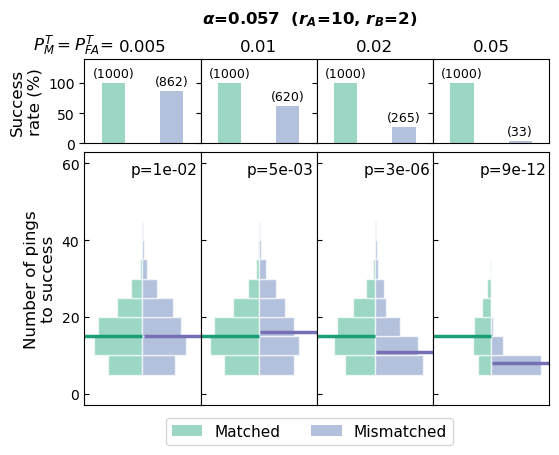

In [9]:
cr = 10
br = 2
# pm_truth_all = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]  # before 20251230
pm_truth_all = [0.005, 0.01, 0.02, 0.05]  # starting 20251230 
pm_agent_all = [0.001] * len(pm_truth_all)

fig = bar_violinplot_success(
    cr, br, pm_agent_all, pm_truth_all,
    success_type="success_2conditions",
    p_max_th=0.95, pmax_diff_threshold=1e-5,
    alpha=0.65, ping_bins=np.arange(0, 155, 5), print_stats=True
)

fig.savefig(path_fig / f"fig_5D_infotaxis_mismatch_agent_truth_cmp_cr{cr}_br{br}.png", dpi=300, bbox_inches="tight")